<p style="text-align: center; font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;">
LoRaWAN Indoor Dataset: Path Loss Modeling
</p>

This notebook fits path loss models using the outputs of `02_Kalman_Filtering.ipynb`. It compares raw and Kalman-filtered path loss targets, estimates model parameters, evaluates prediction quality, and saves the fitted model parameters for `04_Distance_Estimation.ipynb`.

### Log-Distance Path Loss and Shadowing Modeling


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.font_manager import FontProperties

from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit

sns.set_style("darkgrid")
sns.set_context("talk", font_scale=0.9)

In [2]:
TRAIN_PATH = 'Data Files/train_kf.csv'
TEST_PATH = 'Data Files/test_kf.csv'

required_cols = {
    'device_id', 'time',
    'rssi', 'filtered_rssi',
    'exp_pl', 'exp_pl_filtered',
    'distance', 'frequency', 'c_walls', 'w_walls',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr'
}

train_df = pd.read_csv(TRAIN_PATH, parse_dates=['time'])
test_df = pd.read_csv(TEST_PATH, parse_dates=['time'])

missing_train = required_cols - set(train_df.columns)
missing_test = required_cols - set(test_df.columns)

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns. train: {missing_train}, test: {missing_test}. "
        "Rerun 02_Kalman_Filtering.ipynb."
    )

train_df = train_df.sort_values('time').reset_index(drop=True)
test_df = test_df.sort_values('time').reset_index(drop=True)

print("Loaded filtered train/test splits from 02_Kalman_Filtering.ipynb")
print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")
print(f"Train window: {train_df['time'].min()} -> {train_df['time'].max()}")
print(f"Test  window: {test_df['time'].min()} -> {test_df['time'].max()}")

display(train_df.head())
display(test_df.head())

Loaded filtered train/test splits from 02_Kalman_Filtering.ipynb
train_df shape: (1663627, 16)
test_df shape: (415907, 16)
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test  window: 2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00


,device_id,time,rssi,filtered_rssi,exp_pl,exp_pl_filtered,distance,frequency,c_walls,w_walls,co2,humidity,pm25,pressure,temperature,snr
0,ED5,2024-10-01 00:01:07.420593+00:00,-102.0,-102.000000,119.26,119.260000,40,868.1,2,2,440.0,45.46,0.46,313.80,22.41,10.2
1,ED2,2024-10-01 00:01:25.764905+00:00,-66.0,-66.000000,83.26,83.260000,23,867.9,0,2,451.0,40.59,0.43,314.81,22.83,11.0
2,ED4,2024-10-01 00:01:50.313519+00:00,-119.0,-119.000000,136.26,136.260000,37,867.1,0,5,435.0,37.33,0.05,315.54,24.06,-1.8
3,ED5,2024-10-01 00:02:07.467816+00:00,-100.0,-100.993228,117.26,118.253228,40,867.7,2,2,449.0,45.43,0.40,313.84,22.41,10.8
4,ED2,2024-10-01 00:02:25.817808+00:00,-64.0,-64.993228,81.26,82.253228,23,867.7,0,2,451.0,40.57,0.21,314.80,22.84,8.8


,device_id,time,rssi,filtered_rssi,exp_pl,exp_pl_filtered,distance,frequency,c_walls,w_walls,co2,humidity,pm25,pressure,temperature,snr
0,ED4,2025-08-12 17:19:02.126782+00:00,-84.0,-84.0,101.26,101.26,37,868.5,0,5,454.0,36.31,2.50,321.97,29.12,9.2
1,ED0,2025-08-12 17:19:19.243640+00:00,-51.0,-51.0,68.26,68.26,10,867.7,0,0,411.0,35.23,10.15,319.99,29.33,12.0
2,ED3,2025-08-12 17:19:21.750967+00:00,-69.0,-69.0,86.26,86.26,18,868.1,1,2,430.0,24.39,6.00,320.50,42.69,12.0
3,ED1,2025-08-12 17:19:44.308397+00:00,-54.0,-54.0,71.26,71.26,8,867.5,1,0,424.0,35.60,6.02,320.96,29.76,9.0
4,ED5,2025-08-12 17:19:49.123572+00:00,-94.0,-94.0,111.26,111.26,40,867.9,2,2,440.0,40.62,8.27,320.54,27.01,12.0


In [3]:
# Feature Extraction & Model Function Definitions
features = ['distance', 'frequency', 'c_walls', 'w_walls', 'co2', 
            'humidity', 'pm25', 'pressure', 'temperature', 'snr']
X_train = np.column_stack([train_df[feat].values for feat in features])
X_test  = np.column_stack([test_df[feat].values for feat in features])

# Targets: raw and filtered exp_pl
y_train_raw  = train_df['exp_pl'].values
y_test_raw   = test_df['exp_pl'].values
y_train_filt = train_df['exp_pl_filtered'].values
y_test_filt  = test_df['exp_pl_filtered'].values

# LDPLM-MW: using distance, c_walls, w_walls (indices 0,2,3)
def log_distance_path_loss_separate_walls(x, PL_d0, n, L_c, L_w):
    d, c_walls, w_walls = x
    d0 = 1
    return PL_d0 + 10 * n * np.log10(d/d0) + c_walls * L_c + w_walls * L_w

# LDPLM-MW-EP: using all 10 features
def log_distance_path_loss_with_env_params(x, PL_d0, n, L_c, L_w, a_co2, a_hum, a_pm25, a_pres, a_temp, k_snr):
    d, freq, c_walls, w_walls, co2, hum, pm25, pres, temp, snr = x
    d0 = 1
    return (PL_d0 + 10 * n * np.log10(d/d0) + 20*np.log10(freq) +
            c_walls * L_c + w_walls * L_w +
            a_co2 * co2 + a_hum * hum + a_pm25 * pm25 +
            a_pres * pres + a_temp * temp + snr * k_snr)

idx_mw = [0, 2, 3]
idx_ep = list(range(10))

#### Model Fitting & Evaluation (Raw and Filtered)

In [4]:
# Initial guesses
initial_guess_mw = [30, 2, 5, 3]
initial_guess_ep = [30, 2, 5, 3, 0.01, 0.01, 0.01, 0.01, 0.01, 1]

#  Fit on Raw exp_pl 
popt_mw_raw, _ = curve_fit(
    log_distance_path_loss_separate_walls,
    X_train[:, idx_mw].T, y_train_raw, p0=initial_guess_mw, maxfev=100000)
popt_ep_raw, _ = curve_fit(
    log_distance_path_loss_with_env_params,
    X_train[:, idx_ep].T, y_train_raw, p0=initial_guess_ep, maxfev=100000)

# Fit on Filtered exp_pl 
popt_mw_filt, _ = curve_fit(
    log_distance_path_loss_separate_walls,
    X_train[:, idx_mw].T, y_train_filt, p0=initial_guess_mw, maxfev=100000)
popt_ep_filt, _ = curve_fit(
    log_distance_path_loss_with_env_params,
    X_train[:, idx_ep].T, y_train_filt, p0=initial_guess_ep, maxfev=100000)

#  Predictions 
# Raw models
y_pred_mw_raw   = log_distance_path_loss_separate_walls(X_test[:, idx_mw].T, *popt_mw_raw)
y_pred_ep_raw   = log_distance_path_loss_with_env_params(X_test[:, idx_ep].T, *popt_ep_raw)
y_train_pred_mw_raw = log_distance_path_loss_separate_walls(X_train[:, idx_mw].T, *popt_mw_raw)
y_train_pred_ep_raw = log_distance_path_loss_with_env_params(X_train[:, idx_ep].T, *popt_ep_raw)
# Filtered models
y_pred_mw_filt  = log_distance_path_loss_separate_walls(X_test[:, idx_mw].T, *popt_mw_filt)
y_pred_ep_filt  = log_distance_path_loss_with_env_params(X_test[:, idx_ep].T, *popt_ep_filt)
y_train_pred_mw_filt = log_distance_path_loss_separate_walls(X_train[:, idx_mw].T, *popt_mw_filt)
y_train_pred_ep_filt = log_distance_path_loss_with_env_params(X_train[:, idx_ep].T, *popt_ep_filt)

#  Shadowing (train) & Metrics 
shadowing_mw_raw  = y_train_raw - y_train_pred_mw_raw
sigma_mw_raw      = np.std(shadowing_mw_raw)
shadowing_ep_raw  = y_train_raw - y_train_pred_ep_raw
sigma_ep_raw      = np.std(shadowing_ep_raw)
shadowing_mw_filt = y_train_filt - y_train_pred_mw_filt
sigma_mw_filt     = np.std(shadowing_mw_filt)
shadowing_ep_filt = y_train_filt - y_train_pred_ep_filt
sigma_ep_filt     = np.std(shadowing_ep_filt)

# Test metrics
rmse_mw_raw_test  = np.sqrt(mean_squared_error(y_test_raw, y_pred_mw_raw))
r2_mw_raw_test    = r2_score(y_test_raw, y_pred_mw_raw)
rmse_ep_raw_test  = np.sqrt(mean_squared_error(y_test_raw, y_pred_ep_raw))
r2_ep_raw_test    = r2_score(y_test_raw, y_pred_ep_raw)
rmse_mw_filt_test = np.sqrt(mean_squared_error(y_test_filt, y_pred_mw_filt))
r2_mw_filt_test   = r2_score(y_test_filt, y_pred_mw_filt)
rmse_ep_filt_test = np.sqrt(mean_squared_error(y_test_filt, y_pred_ep_filt))
r2_ep_filt_test   = r2_score(y_test_filt, y_pred_ep_filt)

# Train metrics
rmse_mw_raw_train  = np.sqrt(mean_squared_error(y_train_raw, y_train_pred_mw_raw))
r2_mw_raw_train    = r2_score(y_train_raw, y_train_pred_mw_raw)
rmse_ep_raw_train  = np.sqrt(mean_squared_error(y_train_raw, y_train_pred_ep_raw))
r2_ep_raw_train    = r2_score(y_train_raw, y_train_pred_ep_raw)
rmse_mw_filt_train = np.sqrt(mean_squared_error(y_train_filt, y_train_pred_mw_filt))
r2_mw_filt_train   = r2_score(y_train_filt, y_train_pred_mw_filt)
rmse_ep_filt_train = np.sqrt(mean_squared_error(y_train_filt, y_train_pred_ep_filt))
r2_ep_filt_train   = r2_score(y_train_filt, y_train_pred_ep_filt)

#### Parameter & Metrics Comparison

In [5]:
# Parameters from curve fitting
params_mw_raw  = {'PL(d0)': popt_mw_raw[0], 'n': popt_mw_raw[1], 'L_c': popt_mw_raw[2], 'L_w': popt_mw_raw[3]}
params_ep_raw  = {'PL(d0)': popt_ep_raw[0], 'n': popt_ep_raw[1], 'L_c': popt_ep_raw[2], 'L_w': popt_ep_raw[3],
                  'a_co2': popt_ep_raw[4], 'a_hum': popt_ep_raw[5], 'a_pm25': popt_ep_raw[6],
                  'a_pres': popt_ep_raw[7], 'a_temp': popt_ep_raw[8], 'k_snr': popt_ep_raw[9]}
params_mw_filt = {'PL(d0)': popt_mw_filt[0], 'n': popt_mw_filt[1], 'L_c': popt_mw_filt[2], 'L_w': popt_mw_filt[3]}
params_ep_filt = {'PL(d0)': popt_ep_filt[0], 'n': popt_ep_filt[1], 'L_c': popt_ep_filt[2], 'L_w': popt_ep_filt[3],
                  'a_co2': popt_ep_filt[4], 'a_hum': popt_ep_filt[5], 'a_pm25': popt_ep_filt[6],
                  'a_pres': popt_ep_filt[7], 'a_temp': popt_ep_filt[8], 'k_snr': popt_ep_filt[9]}

# Build table of parameters for all 4 models
shared_params = ['PL(d0)', 'n', 'L_c', 'L_w']
unique_params = ['a_co2', 'a_hum', 'a_pm25', 'a_pres', 'a_temp', 'k_snr']
parameter_list = shared_params + unique_params

ldplm_mw_raw_vals  = [params_mw_raw.get(p, '-') for p in parameter_list]
ldplm_ep_raw_vals  = [params_ep_raw.get(p, '-') for p in parameter_list]
ldplm_mw_filt_vals = [params_mw_filt.get(p, '-') for p in parameter_list]
ldplm_ep_filt_vals = [params_ep_filt.get(p, '-') for p in parameter_list]

params_comp_df = pd.DataFrame({
    'MWM': ldplm_mw_raw_vals,
    'MWM-KF': ldplm_mw_filt_vals,
    'MWM-EP': ldplm_ep_raw_vals,
    'MWM-EP-KF': ldplm_ep_filt_vals
}, index=parameter_list)

# Build Metrics DataFrame
metrics = ['RMSE (Train)', 'RMSE (Test)', 'R2 (Train)', 'R2 (Test)', 'σ (dB)']
metrics_df = pd.DataFrame({
    'MWM': [rmse_mw_raw_train, rmse_mw_raw_test, r2_mw_raw_train, r2_mw_raw_test, sigma_mw_raw],
    'MWM-KF': [rmse_mw_filt_train, rmse_mw_filt_test, r2_mw_filt_train, r2_mw_filt_test, sigma_mw_filt],
    'MWM-EP': [rmse_ep_raw_train, rmse_ep_raw_test, r2_ep_raw_train, r2_ep_raw_test, sigma_ep_raw],
    'MWM-EP-KF': [rmse_ep_filt_train, rmse_ep_filt_test, r2_ep_filt_train, r2_ep_filt_test, sigma_ep_filt],
}, index=metrics)

print("\nTable of Parameters to be Compared")
display(params_comp_df)

print("\nPerformance Metrics")
display(metrics_df)


Table of Parameters to be Compared


,MWM,MWM-KF,MWM-EP,MWM-EP-KF
PL(d0),26.020828,26.021784,2.305555,-18.400395
n,4.227222,4.227134,3.866506,4.163663
L_c,7.800833,7.801118,6.830244,7.742712
L_w,1.694781,1.694934,1.977093,1.683637
a_co2,-,-,-0.002355,-0.004319
a_hum,-,-,-0.091712,-0.107795
a_pm25,-,-,-0.095295,-0.115168
a_pres,-,-,-0.008046,0.002301
a_temp,-,-,-0.141028,-0.177546
k_snr,-,-,-2.034426,-0.371448



Performance Metrics


,MWM,MWM-KF,MWM-EP,MWM-EP-KF
RMSE (Train),10.706810,5.775313,8.038889,5.531961
RMSE (Test),12.070219,5.559576,8.453448,5.398016
R2 (Train),0.676197,0.877712,0.817462,0.887800
R2 (Test),0.589036,0.871052,0.798423,0.878437
σ (dB),10.706810,5.775313,8.038889,5.531961


In [6]:
np.savez(
    'Data Files/path_loss_params.npz',
    popt_mw_raw=popt_mw_raw,
    popt_ep_raw=popt_ep_raw,
    popt_mw_filt=popt_mw_filt,
    popt_ep_filt=popt_ep_filt
)

params_comp_df.to_csv('Data Files/path_loss_params_table.csv')
metrics_df.to_csv('Data Files/path_loss_metrics.csv')

print("Saved:")
print("  Data Files/path_loss_params.npz")
print("  Data Files/path_loss_params_table.csv")
print("  Data Files/path_loss_metrics.csv")

Saved:
  Data Files/path_loss_params.npz
  Data Files/path_loss_params_table.csv
  Data Files/path_loss_metrics.csv


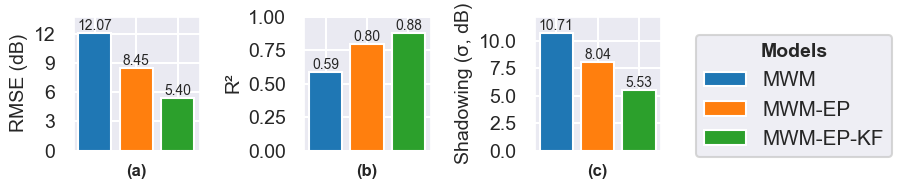

In [7]:
# Subset of models we want to compare
model_subset = ['MWM', 'MWM-EP', 'MWM-EP-KF']

# Extract the relevant test metrics from your metrics_df
rmse_test_values = metrics_df.loc['RMSE (Test)', model_subset]
r2_test_values   = metrics_df.loc['R2 (Test)', model_subset]
sigma_values     = metrics_df.loc['σ (dB)', model_subset]  # Shadowing

# Create figure and subplots
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(7, 2.2))

# Define a color scheme for the three bars
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# (a) RMSE(Test)
bars_a = axs[0].bar(model_subset, rmse_test_values, color=colors)
axs[0].set_ylabel('RMSE (dB)', fontsize=14)
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[0].tick_params(axis='y', labelsize=14)
axs[0].text(0.5, -0.1, '(a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', ha='center', va='top')
# Label each bar in subplot (a) for the legend
for bar, label in zip(bars_a, model_subset):
    bar.set_label(label)

# (b) R²(Test)
axs[1].bar(model_subset, r2_test_values, color=colors)
axs[1].set_ylabel('R²', fontsize=14)
axs[1].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', labelsize=14)
axs[1].text(0.5, -0.1, '(b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', ha='center', va='top')

# (c) Shadowing (σ dB)
axs[2].bar(model_subset, sigma_values, color=colors)
axs[2].set_ylabel('Shadowing (σ, dB)', fontsize=14)
axs[2].tick_params(axis='x', bottom=False, labelbottom=False)
axs[2].tick_params(axis='y', labelsize=14)
axs[2].text(0.5, -0.1, '(c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', ha='center', va='top')

# Set each subplot's y-axis to have about 5 ticks using MaxNLocator
for ax in axs:
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Set border (spine) width for both subplots
for ax in axs:
    [s.set_linewidth(2) for s in ax.spines.values()]
    # Annotate bar values safely
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    (bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10,
                    clip_on=True)  # <- ensures text stays inside the axes

# Add headroom for bar labels
for ax in axs:
    y_max = max([bar.get_height() for bar in ax.patches])
    ax.set_ylim(top=y_max * 1.15)  # 15% headroom
    
# Create one combined legend on the right-hand side with a bold title
handles, labels = axs[0].get_legend_handles_labels()
legend = fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1,
                    title='Models')
legend.get_title().set_fontsize(14)
legend.get_title().set_fontweight('bold')

# Adjust layout to account for the legend on the right and reduce the white gap at the bottom
plt.subplots_adjust(right=0.85, bottom=0.15)
plt.tight_layout()

# Save the figure at high resolution
#plt.savefig('../all_data_files/Localization/rmse_r2_comparison.png', dpi=2000, bbox_inches='tight')
plt.show()

### Combined Plots (Raw & Filtered) and Residual Distribution Table

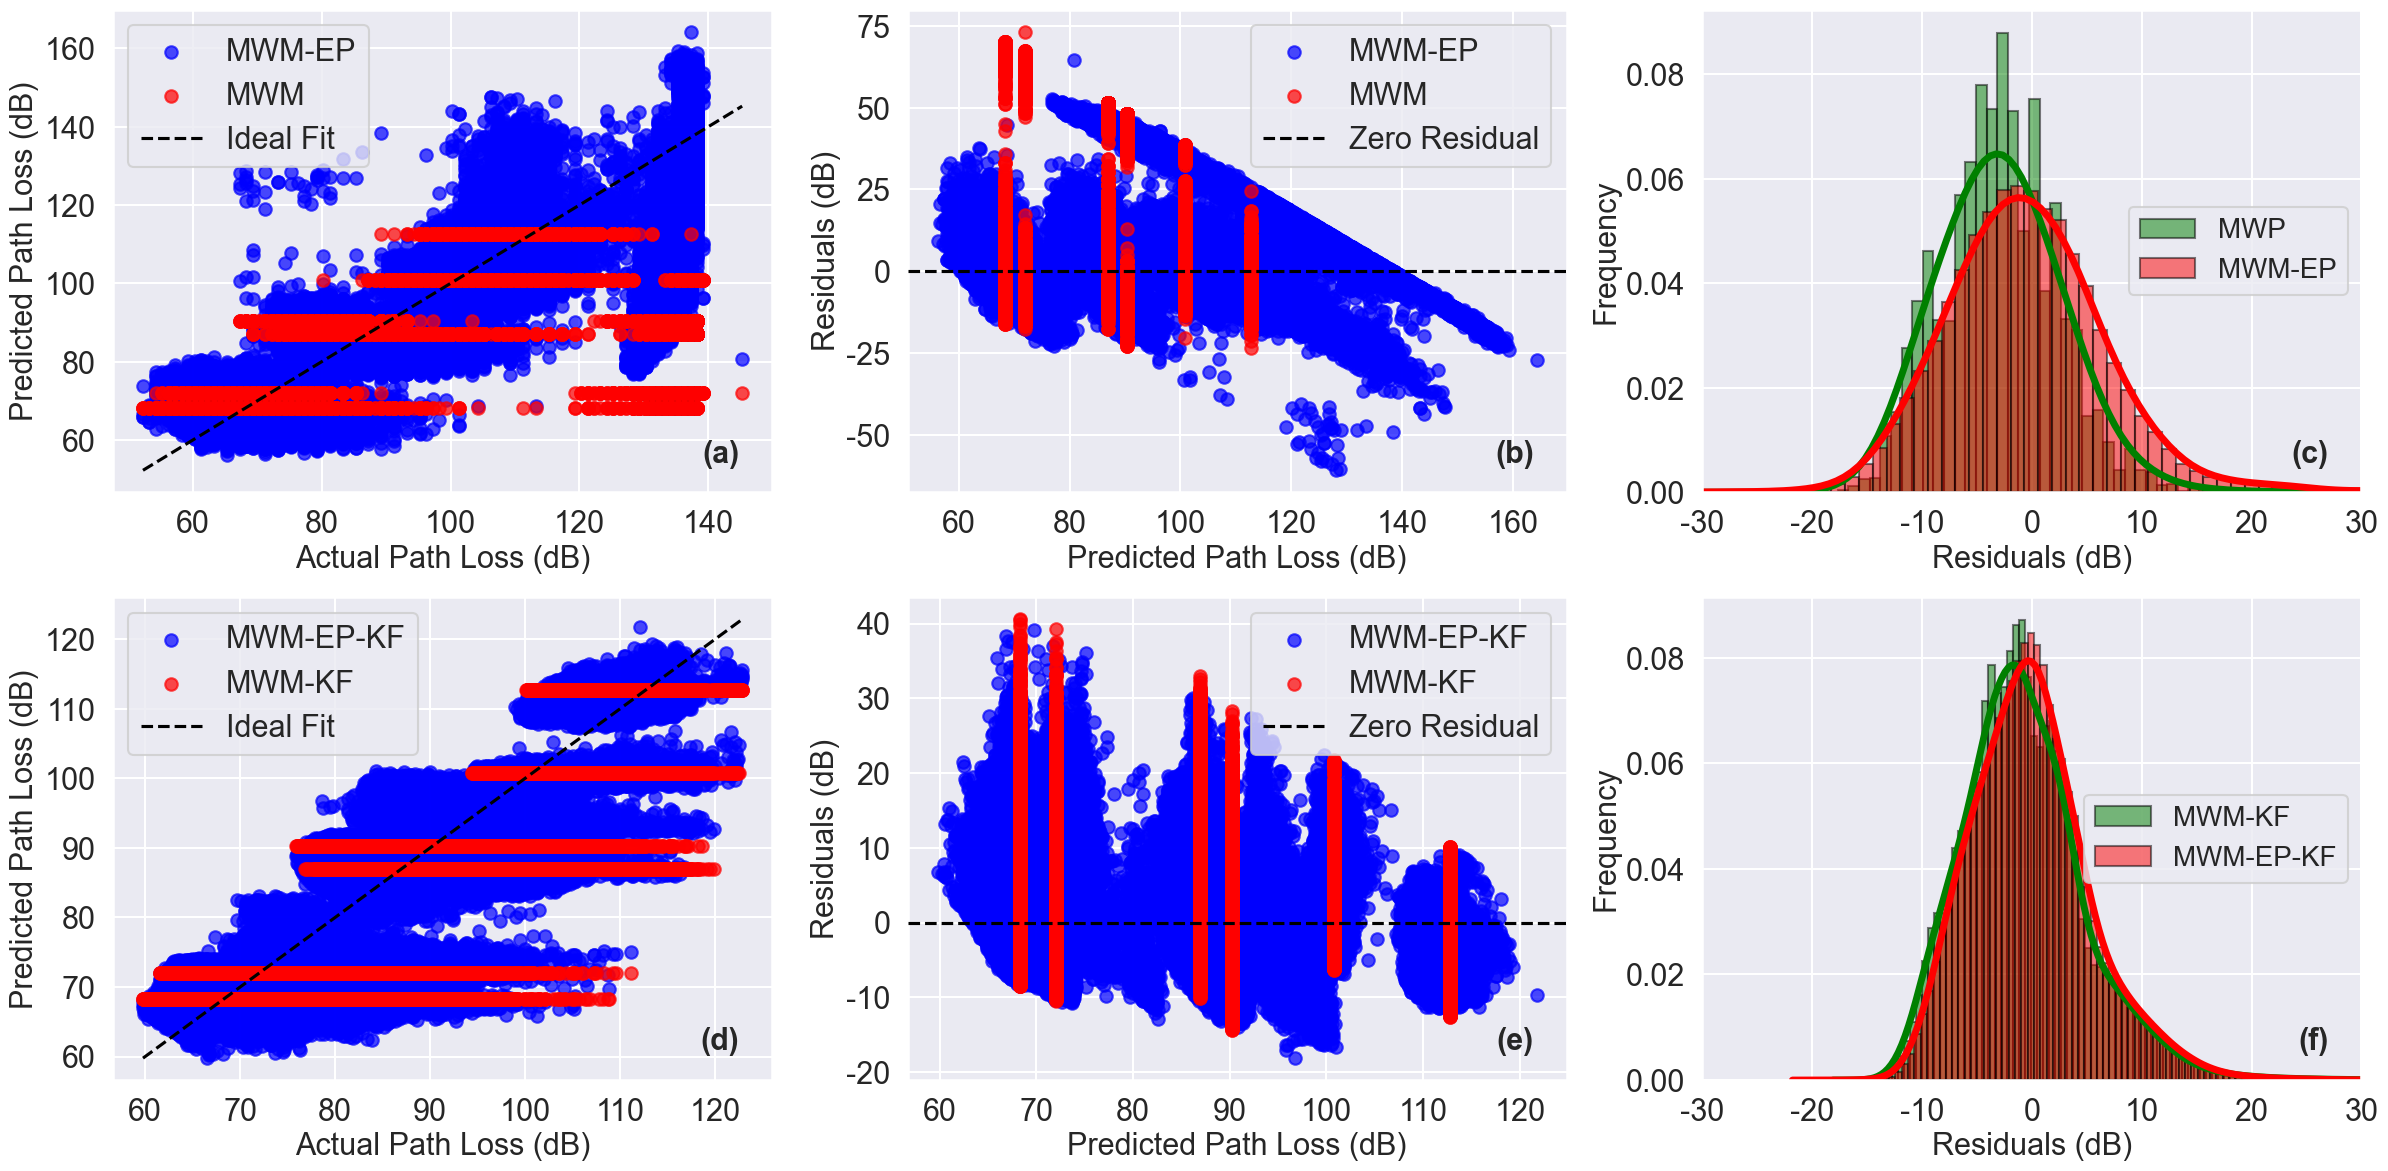


Residual Distribution Values:


,Mean (dB),Skewness
MWM,-0.720112,3.623528
MWM-KF,-0.719805,0.770463
MWM-EP,-0.100137,1.567139
MWM-EP-KF,-0.057018,0.667356


In [8]:
# Compute test residuals for raw and filtered models
residuals_mw_test = y_test_raw - y_pred_mw_raw
residuals_ep_test = y_test_raw - y_pred_ep_raw
residuals_mw_test_filt = y_test_filt - y_pred_mw_filt
residuals_ep_test_filt = y_test_filt - y_pred_ep_filt

# Define plotting targets/predictions (raw & filtered)
PL_test_mw = y_test_raw        # Raw target for MW & EP (identical)
PL_test_ep = y_test_raw
PL_pred_mw = y_pred_mw_raw     # Raw predictions
PL_pred_ep = y_pred_ep_raw

PL_test_mw_filt = y_test_filt  # Filtered targets for MW & EP (identical)
PL_test_ep_filt = y_test_filt
PL_pred_mw_filt = y_pred_mw_filt  # Filtered predictions
PL_pred_ep_filt = y_pred_ep_filt

# Define ideal fit line boundaries
min_PL = min(PL_test_ep.min(), PL_test_mw.min())
max_PL = max(PL_test_ep.max(), PL_test_mw.max())
min_PL_filt = min(PL_test_ep_filt.min(), PL_test_mw_filt.min())
max_PL_filt = max(PL_test_ep_filt.max(), PL_test_mw_filt.max())

# Create a figure with 2 rows x 3 columns (Row 1: Raw, Row 2: Filtered)
fig, axes = plt.subplots(2, 3, figsize=(24, 12))

#  Row 1: Raw Models 
# (a) Actual vs Predicted Path Loss
ax = axes[0, 0]
ax.scatter(PL_test_ep, PL_pred_ep, alpha=0.7, label='MWM-EP', color='blue', zorder=2)
ax.scatter(PL_test_mw, PL_pred_mw, alpha=0.7, label='MWM', color='red', zorder=3)
ax.plot([min_PL, max_PL], [min_PL, max_PL], 'k--', label='Ideal Fit', zorder=4)
ax.set_xlabel('Actual Path Loss (dB)', fontsize=22)
ax.set_ylabel('Predicted Path Loss (dB)', fontsize=22)
ax.legend(fontsize=22, loc='upper left')
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.text(0.95, 0.05, '(a)', transform=ax.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')

# (b) Residuals vs Predicted Path Loss
ax = axes[0, 1]
ax.scatter(PL_pred_ep, residuals_ep_test, alpha=0.7, label='MWM-EP', color='blue', zorder=2)
ax.scatter(PL_pred_mw, residuals_mw_test, alpha=0.7, label='MWM', color='red', zorder=3)
ax.axhline(0, color='k', linestyle='--', label='Zero Residual', zorder=4)
ax.set_xlabel('Predicted Path Loss (dB)', fontsize=22)
ax.set_ylabel('Residuals (dB)', fontsize=22)
ax.legend(fontsize=22, loc='upper right')
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')

# (c) Histogram & KDE of Residuals
ax = axes[0, 2]
ax.hist(residuals_mw_test, bins=100, alpha=0.5, label='MWP', color='green', edgecolor='k', density=True)
ax.hist(residuals_ep_test, bins=100, alpha=0.5, label='MWM-EP', color='red', edgecolor='k', density=True)
sns.kdeplot(residuals_mw_test, color='green', bw_adjust=3, ax=ax, linewidth=5)
sns.kdeplot(residuals_ep_test, color='red', bw_adjust=3, ax=ax, linewidth=5)
ax.set_xlabel('Residuals (dB)', fontsize=22)
ax.set_ylabel('Frequency', fontsize=22)
ax.set_xlim(-30, 30)
ax.legend(fontsize=20, loc='center right')
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.text(0.95, 0.05, '(c)', transform=ax.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')

#  Row 2: Filtered Models 
# (d) Actual vs Predicted Path Loss (Filtered)
ax = axes[1, 0]
ax.scatter(PL_test_ep_filt, PL_pred_ep_filt, alpha=0.7, label='MWM-EP-KF', color='blue', zorder=2)
ax.scatter(PL_test_mw_filt, PL_pred_mw_filt, alpha=0.7, label='MWM-KF', color='red', zorder=3)
ax.plot([min_PL_filt, max_PL_filt], [min_PL_filt, max_PL_filt], 'k--', label='Ideal Fit', zorder=4)
ax.set_xlabel('Actual Path Loss (dB)', fontsize=22)
ax.set_ylabel('Predicted Path Loss (dB)', fontsize=22)
ax.legend(fontsize=22, loc='upper left')
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.text(0.95, 0.05, '(d)', transform=ax.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')

# (e) Residuals vs Predicted Path Loss (Filtered)
ax = axes[1, 1]
ax.scatter(PL_pred_ep_filt, residuals_ep_test_filt, alpha=0.7, label='MWM-EP-KF', color='blue', zorder=2)
ax.scatter(PL_pred_mw_filt, residuals_mw_test_filt, alpha=0.7, label='MWM-KF', color='red', zorder=3)
ax.axhline(0, color='k', linestyle='--', label='Zero Residual', zorder=4)
ax.set_xlabel('Predicted Path Loss (dB)', fontsize=22)
ax.set_ylabel('Residuals (dB)', fontsize=22)
ax.legend(fontsize=22, loc='upper right')
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.text(0.95, 0.05, '(e)', transform=ax.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')

# (f) Histogram & KDE of Residuals (Filtered)
ax = axes[1, 2]
ax.hist(residuals_mw_test_filt, bins=100, alpha=0.5, label='MWM-KF', color='green', edgecolor='k', density=True)
ax.hist(residuals_ep_test_filt, bins=100, alpha=0.5, label='MWM-EP-KF', color='red', edgecolor='k', density=True)
sns.kdeplot(residuals_mw_test_filt, color='green', bw_adjust=3, ax=ax, linewidth=5)
sns.kdeplot(residuals_ep_test_filt, color='red', bw_adjust=3, ax=ax, linewidth=5)
ax.set_xlabel('Residuals (dB)', fontsize=22)
ax.set_ylabel('Frequency', fontsize=22)
ax.set_xlim(-30, 30)
ax.legend(fontsize=20, loc='center right')
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.text(0.95, 0.05, '(f)', transform=ax.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')

plt.tight_layout()
#plt.savefig('../all_data_files/All_Plots_as_Subplots_Kalman.png', dpi=1000)
plt.show()

#  Residual Distribution Table (Test Data) 
resid_mean_mw      = round(np.mean(residuals_mw_test), 6)
resid_skew_mw      = round(pd.Series(residuals_mw_test).skew(), 6)
resid_mean_ep      = round(np.mean(residuals_ep_test), 6)
resid_skew_ep      = round(pd.Series(residuals_ep_test).skew(), 6)
resid_mean_mw_filt = round(np.mean(residuals_mw_test_filt), 6)
resid_skew_mw_filt = round(pd.Series(residuals_mw_test_filt).skew(), 6)
resid_mean_ep_filt = round(np.mean(residuals_ep_test_filt), 6)
resid_skew_ep_filt = round(pd.Series(residuals_ep_test_filt).skew(), 6)

resid_df = pd.DataFrame({
    'Mean (dB)': [resid_mean_mw, resid_mean_mw_filt, resid_mean_ep, resid_mean_ep_filt],
    'Skewness': [resid_skew_mw, resid_skew_mw_filt, resid_skew_ep, resid_skew_ep_filt]
}, index=['MWM', 'MWM-KF', 'MWM-EP', 'MWM-EP-KF'])

print("\nResidual Distribution Values:")
display(resid_df)

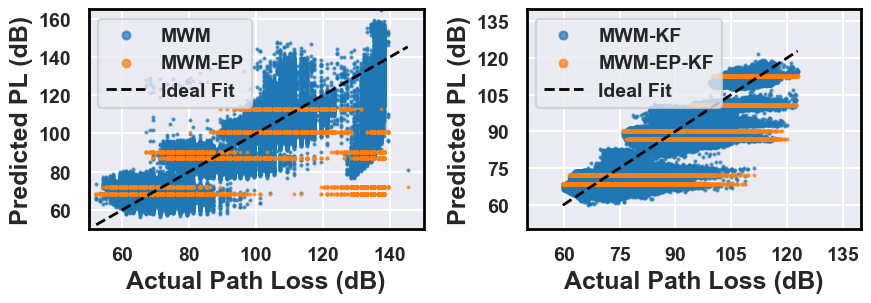

In [9]:
# fonts for PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['savefig.dpi']  = 300   # for any rasterized bits

def subsample_xy(x, y, max_points=1000000, seed=0):
    """
    Randomly subsample paired arrays (x, y) to at most max_points.
    Keeps x and y aligned and is deterministic via seed.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    if n <= max_points:
        return x, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_points, replace=False)
    return x[idx], y[idx]

# Subsample each cloud separately (tweakeable)
PL_test_ep_sub,   PL_pred_ep_sub   = subsample_xy(PL_test_ep,      PL_pred_ep,      max_points=1000000, seed=1)
PL_test_mw_sub,   PL_pred_mw_sub   = subsample_xy(PL_test_mw,      PL_pred_mw,      max_points=1000000, seed=2)
PL_test_ep_f_sub, PL_pred_ep_f_sub = subsample_xy(PL_test_ep_filt, PL_pred_ep_filt, max_points=1000000, seed=3)
PL_test_mw_f_sub, PL_pred_mw_f_sub = subsample_xy(PL_test_mw_filt, PL_pred_mw_filt, max_points=1000000, seed=4)

# Legend font (change size here and it WILL change)
legend_font_left  = FontProperties(weight='bold', size=14)
legend_font_right = FontProperties(weight='bold', size=14)

# Create a figure with 1 row x 2 columns
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))

# (a) Raw Models
ax_left = axs[0]
ax_left.scatter(PL_test_ep_sub, PL_pred_ep_sub,
                s=2, alpha=0.7, label='MWM',
                color='#1f77b4', zorder=2, rasterized=True)
ax_left.scatter(PL_test_mw_sub, PL_pred_mw_sub,
                s=2, alpha=0.7, label='MWM-EP',
                color='#ff7f0e', zorder=3, rasterized=True)
ax_left.plot([min_PL, max_PL], [min_PL, max_PL], 'k--', linewidth=2, label='Ideal Fit', zorder=4)
ax_left.set_xlabel('Actual Path Loss (dB)', fontsize=18, fontweight='bold')
ax_left.set_ylabel('Predicted PL (dB)', fontsize=18, fontweight='bold')
ax_left.grid(True)
ax_left.tick_params(axis='both', which='major', labelsize=14)
ax_left.legend(loc='upper left', markerscale=4,
               prop=legend_font_left) 

# (b) Filtered Models
ax_right = axs[1]
ax_right.scatter(PL_test_ep_f_sub, PL_pred_ep_f_sub,
                 s=2, alpha=0.7, label='MWM-KF',
                 color='#1f77b4', zorder=2, rasterized=True)
ax_right.scatter(PL_test_mw_f_sub, PL_pred_mw_f_sub,
                 s=2, alpha=0.7, label='MWM-EP-KF',
                 color='#ff7f0e', zorder=3, rasterized=True)
ax_right.plot([min_PL_filt, max_PL_filt], [min_PL_filt, max_PL_filt],
              'k--', linewidth=2, label='Ideal Fit', zorder=4)
ax_right.set_xlabel('Actual Path Loss (dB)', fontsize=18, fontweight='bold')
ax_right.set_ylabel('Predicted PL (dB)', fontsize=18, fontweight='bold')
ax_right.grid(True)
ax_right.tick_params(axis='both', which='major', labelsize=14)
ax_right.legend(loc='upper left', markerscale=4,
                prop=legend_font_right) 

#  Axes limits + uniform tick control 
ax_left.set_xlim(50, 150)
ax_left.set_ylim(50, 165)
ax_right.set_xlim(50, 140)
ax_right.set_ylim(50, 140)

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

# Set all subplot borders (spines) to width 2 and bold ticks
for ax in axs:
    for s in ax.spines.values():
        s.set_linewidth(2)
        s.set_color('black')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('../all_data_files/Localization/Kalman_vs_Raw_Residuals.pdf', bbox_inches='tight')
plt.savefig('../all_data_files/Localization/Kalman_vs_Raw_Residuals.png', dpi=1000, bbox_inches='tight')
plt.show()